# MNIST in PyTorch
## A handwritten digit classifier built from scratch

### What is MNIST
28x28 grayscale images of handwritten digits (0-9).
60,000 training samples, 10,000 test samples.
Goal: classify each image as the correct digit.

### Imports
- `torch` — core PyTorch
- `torch.nn` — neural network building blocks (layers, activations, loss functions)
- `torch.optim` — optimisers (e.g. SGD, Adam)
- `torchvision` — datasets and image transforms
- `DataLoader` — batches and shuffles data for training
- `matplotlib` — visualising images and results

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 

### Loading MNIST
PyTorch's torchvision library includes MNIST as a built-in dataset.
We apply a transform to convert raw images to tensors.
DataLoader wraps the dataset to serve it in batches during training.

In [3]:
# Transform: cconvert images to tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load training data
train_datasset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Wrap in DataLoaders
train_loader = DataLoader(train_datasset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100.0%
100.0%
100.0%
100.0%


### Inspecting teh Data
Before building the model, we check shapes and visualise samples.
This confirms the data loaded correctly and builds intuition.

Batch shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64, 1, 28, 28])
First label: 3


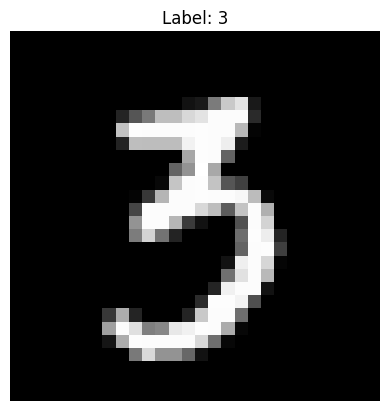

In [4]:
# Check on batch
images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)
print("Labels shape:", images.shape)
print("First label:", labels[0].item())

# Visualise one image
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.axis('off')
plt.show()

### Building the Model
We define a simple 2-layer neural network using PyTorch's nn.Module.
Each image is flattened from (1, 28, 28) to 784 inputs.
The network maps 748 inputs -> 128 hidden neurons -> 10 output classes.
Output layer uses softmax to produce a probability distribution over the 10 digits.

In [6]:
class MNISTNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MNISTNet()
print(model)

MNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Training Loop
We train the model for a number of epochs.
Each epoch: iterate through batches, forward pass, calculate loss, backpropogate, update weights 

In [8]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    for images, labels in train_loader:
        
        # Forward pass
        predictions = model(images)
        loss = loss_function(predictions, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {total_loss/len(train_loader):.4f}")

Epoch 1/5 - loss: 0.4312
Epoch 2/5 - loss: 0.1568
Epoch 3/5 - loss: 0.1164
Epoch 4/5 - loss: 0.0932
Epoch 5/5 - loss: 0.0786


### Evaluation
We test the module on unseen data to measure accuracy.
The model is set to eval mode to disable any training-specific behaviour.

In [11]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        predictions = model(images)
        predicted_classes = torch.argmax(predictions, dim=1)
        correct += (predicted_classes == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.11%
